In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/codveda level 2 task 1 2 3/2 Stock Prices Data Set coddeva.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(497472, 7)
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
print("Total unique symbols:", df['symbol'].nunique())
print("\nSample symbols:", df['symbol'].unique()[:20])

Total unique symbols: 505

Sample symbols: ['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADSK' 'ADS' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG']


In [ ]:
apple = df[df['symbol'] == 'AAPL'].copy()
print("AAPL rows:", len(apple))
print("Date range:", apple['date'].min(), "→", apple['date'].max())
apple.head()

AAPL rows: 1007
Date range: 2014-01-02 → 2017-12-29


,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/codveda level 2 task 1 2 3/2 Stock Prices Data Set coddeva.csv')

# Filter Apple only
apple = df[df['symbol'] == 'AAPL'].copy()

# Convert date to datetime and set as index
apple['date'] = pd.to_datetime(apple['date'])
apple = apple.sort_values('date')
apple.set_index('date', inplace=True)

print(" Dataset prepared!")
print(f"Company        : Apple Inc. (AAPL)")
print(f"Total rows     : {len(apple)}")
print(f"Date range     : {apple.index.min().date()} → {apple.index.max().date()}")
print(f"Columns        : {apple.columns.tolist()}")
apple.head()

 Dataset prepared!
Company        : Apple Inc. (AAPL)
Total rows     : 1007
Date range     : 2014-01-02 → 2017-12-29
Columns        : ['symbol', 'open', 'high', 'low', 'close', 'volume']


,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


In [ ]:
print("=" * 45)
print("APPLE STOCK — BASIC STATISTICS")
print("=" * 45)
print(apple[['open', 'high', 'low', 'close', 'volume']].describe().round(2))

print(f"\n Highest closing price : ${apple['close'].max():.2f}")
print(f" Lowest closing price  : ${apple['close'].min():.2f}")
print(f" Average closing price : ${apple['close'].mean():.2f}")
print(f" Price change overall  : ${apple['close'].iloc[-1] - apple['close'].iloc[0]:.2f}")

APPLE STOCK — BASIC STATISTICS
          open     high      low    close        volume
count  1007.00  1007.00  1007.00  1007.00  1.007000e+03
mean    116.81   117.75   115.86   116.84  4.516957e+07
std      24.56    24.62    24.43    24.55  2.490233e+07
min      70.74    71.65    70.51    71.40  1.147592e+07
25%      98.88   100.13    98.28    99.02  2.743226e+07
50%     113.05   114.19   111.97   113.05  3.923261e+07
75%     129.22   130.54   128.32   129.36  5.558268e+07
max     175.11   177.20   174.86   176.42  2.668336e+08

 Highest closing price : $176.42
 Lowest closing price  : $71.40
 Average closing price : $116.84
 Price change overall  : $90.21


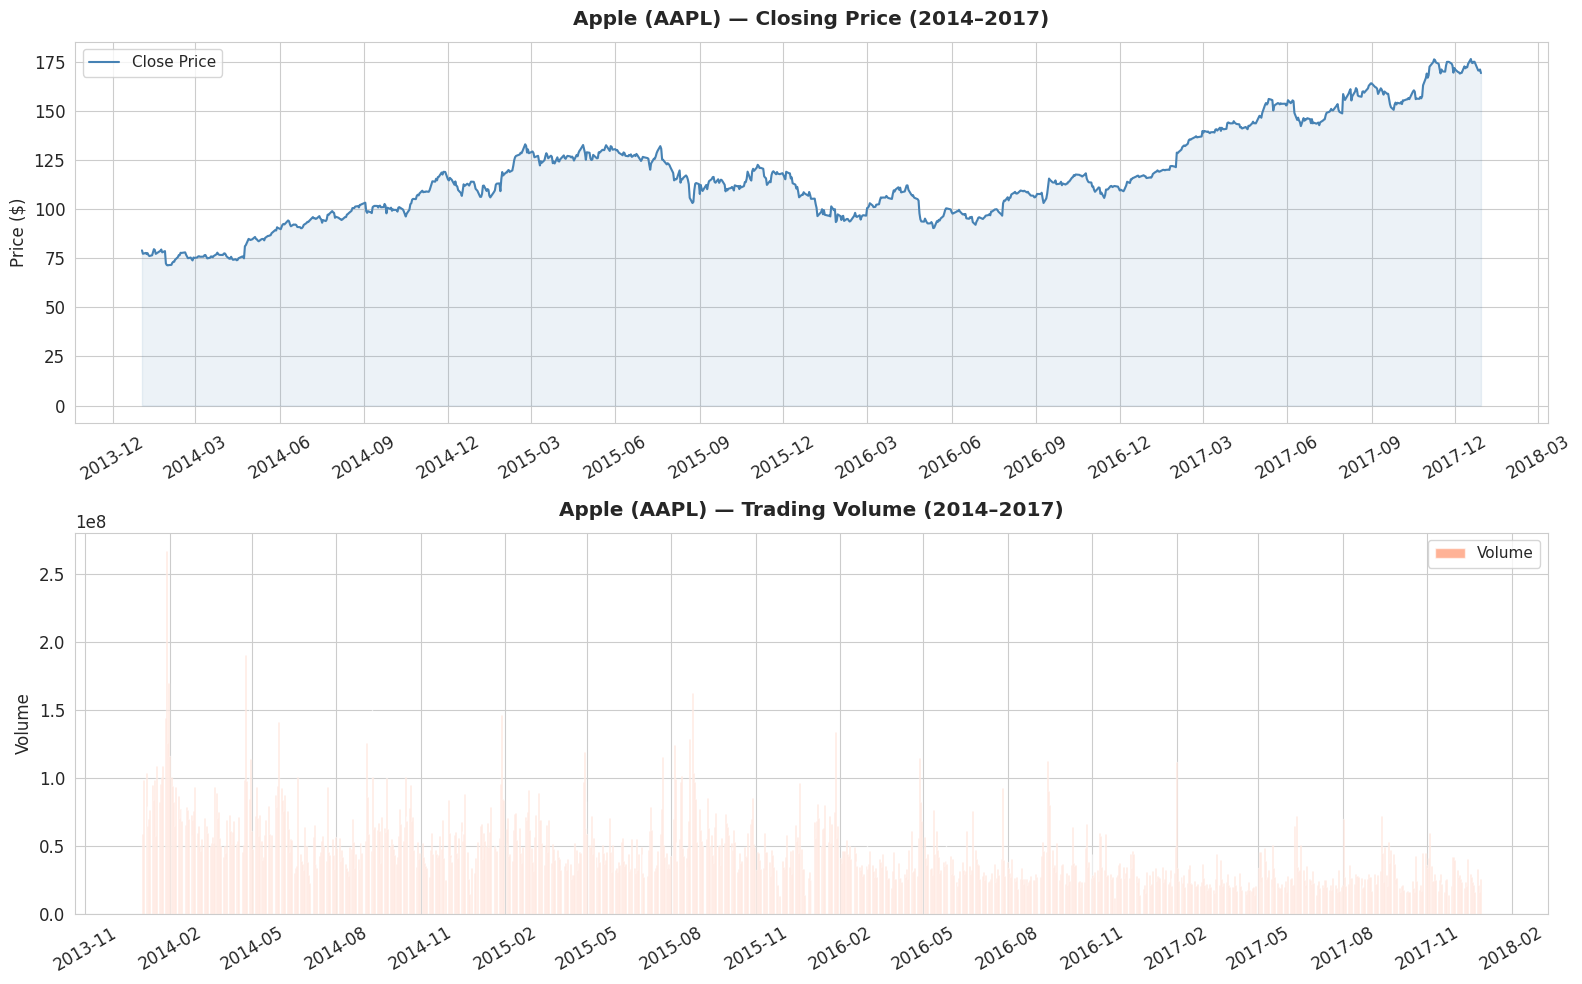

 Saved: raw_time_series.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Closing price
axes[0].plot(apple.index, apple['close'],
             color='steelblue', linewidth=1.5, label='Close Price')
axes[0].fill_between(apple.index, apple['close'],
                     alpha=0.1, color='steelblue')
axes[0].set_title('Apple (AAPL) — Closing Price (2014–2017)',
                  fontweight='bold', pad=12)
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Volume
axes[1].bar(apple.index, apple['volume'],
            color='coral', alpha=0.6, width=1, label='Volume')
axes[1].set_title('Apple (AAPL) — Trading Volume (2014–2017)',
                  fontweight='bold', pad=12)
axes[1].set_ylabel('Volume')
axes[1].legend(fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('raw_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: raw_time_series.png")

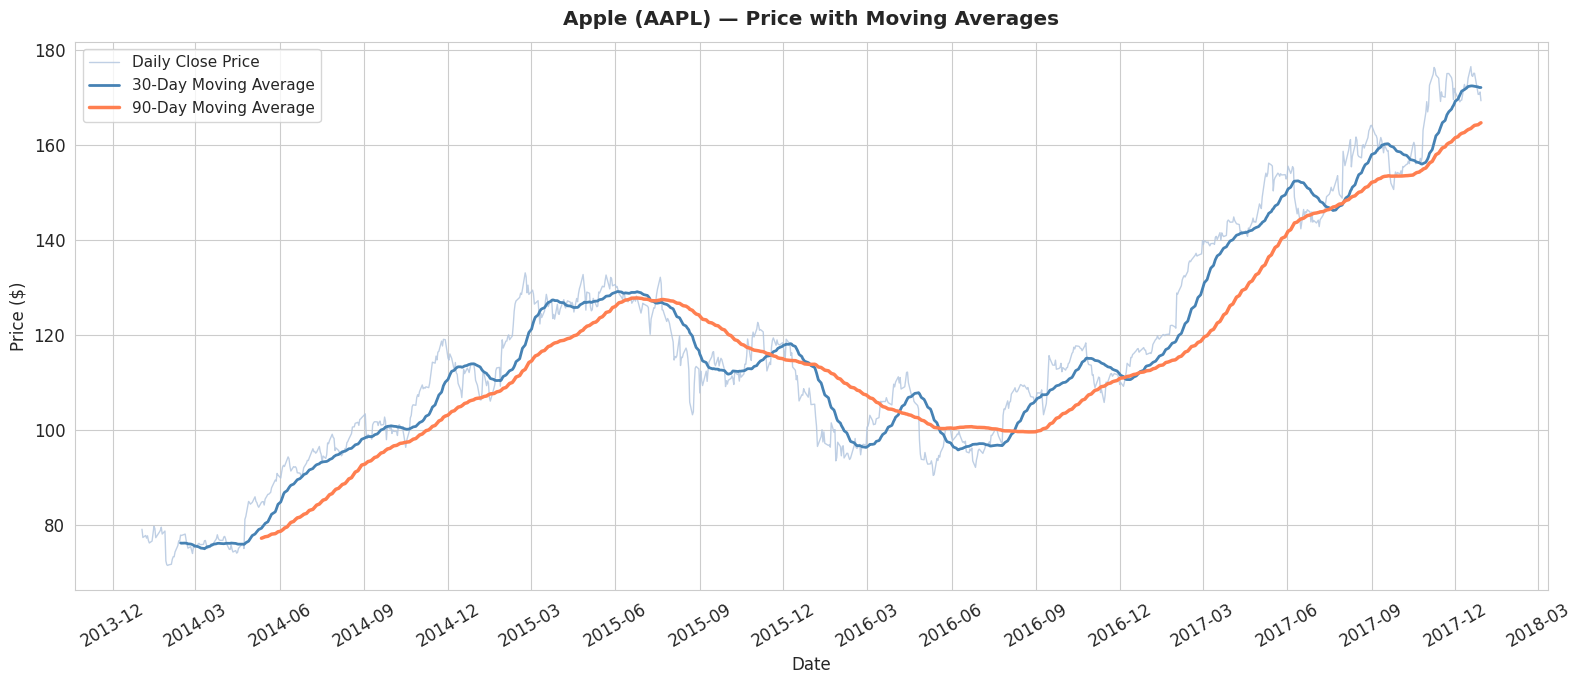

 Saved: moving_averages.png


In [ ]:
apple['MA30'] = apple['close'].rolling(window=30).mean()
apple['MA90'] = apple['close'].rolling(window=90).mean()

plt.figure(figsize=(16, 7))

plt.plot(apple.index, apple['close'],
         color='lightsteelblue', linewidth=1,
         alpha=0.8, label='Daily Close Price')

plt.plot(apple.index, apple['MA30'],
         color='steelblue', linewidth=2,
         label='30-Day Moving Average')

plt.plot(apple.index, apple['MA90'],
         color='coral', linewidth=2.5,
         label='90-Day Moving Average')

plt.title('Apple (AAPL) — Price with Moving Averages',
          fontweight='bold', pad=12)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend(fontsize=11)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: moving_averages.png")

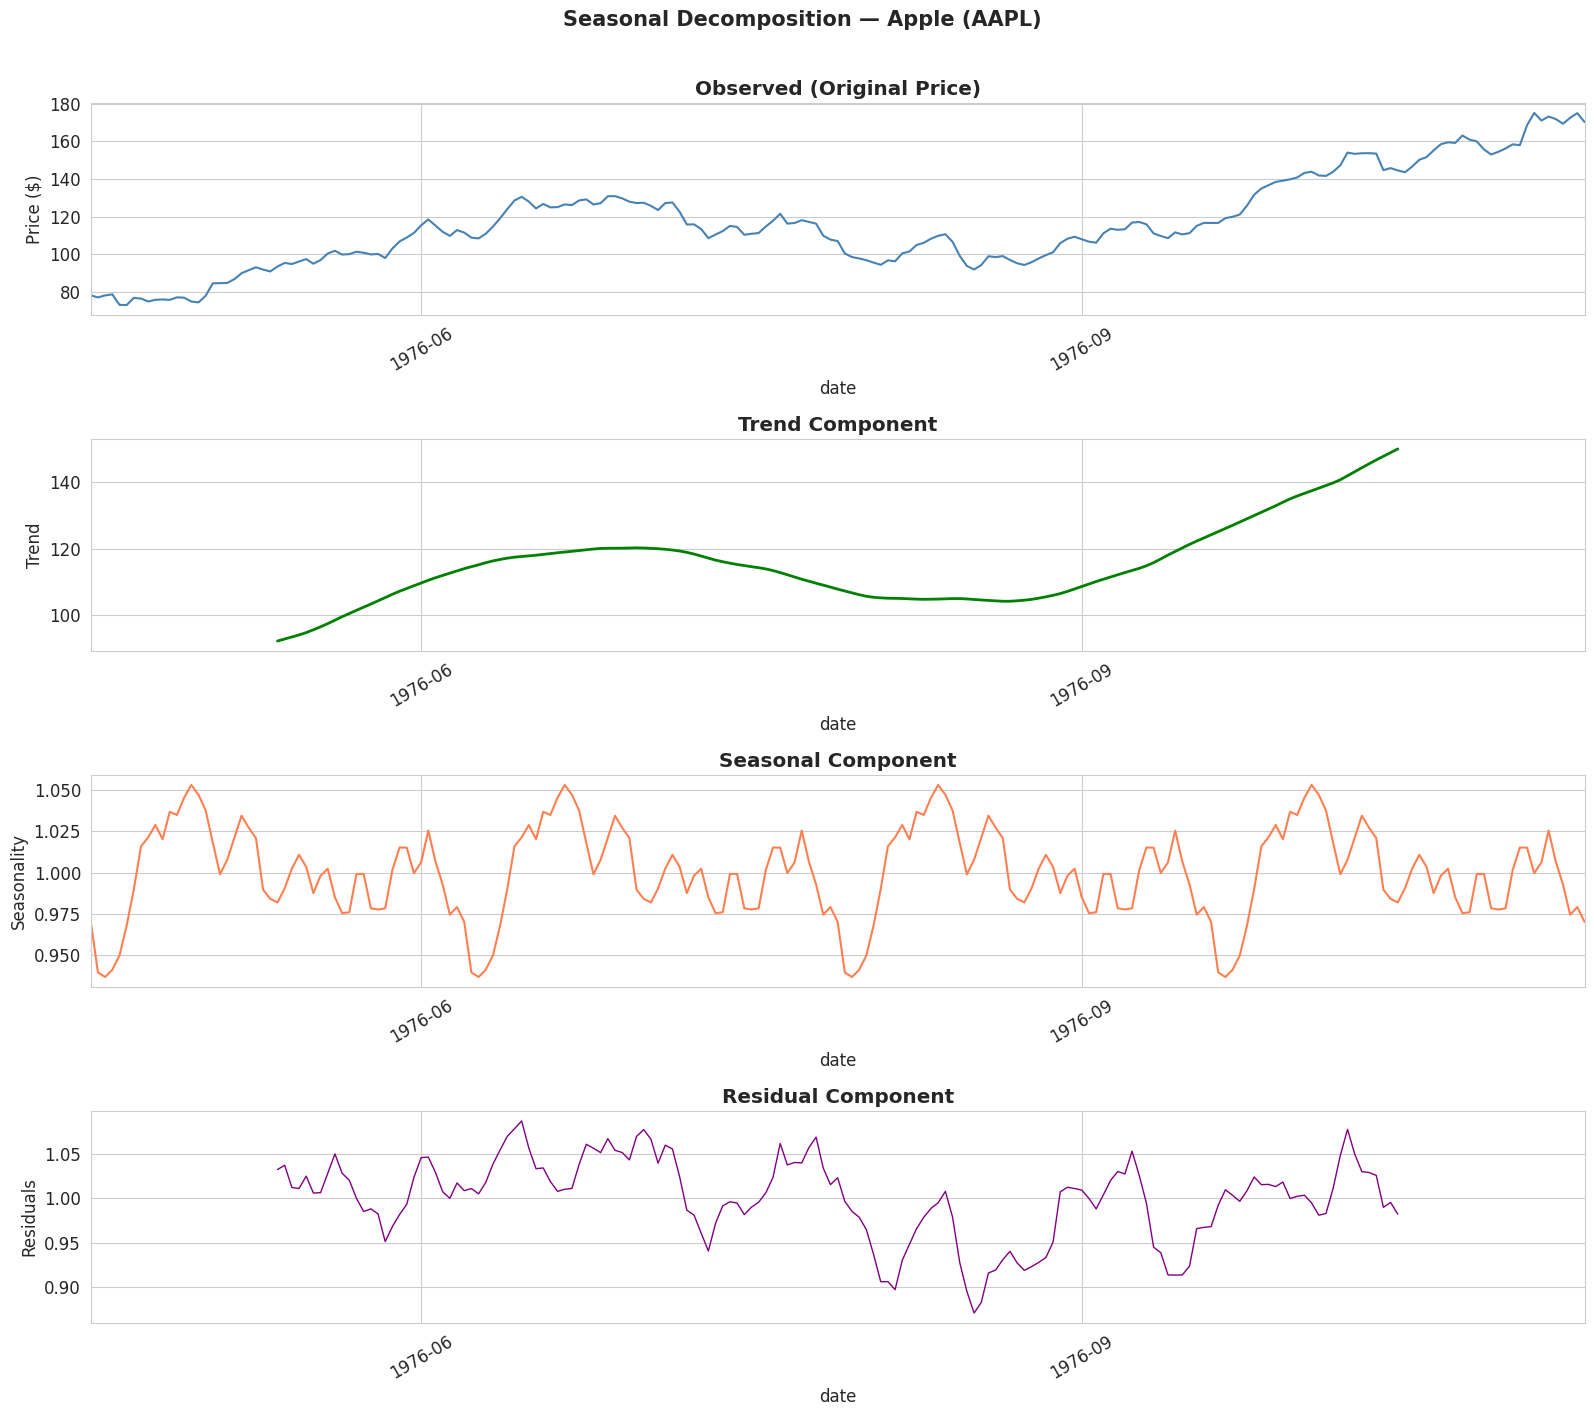

 Saved: seasonal_decomposition.png


In [ ]:
# Resample to weekly for cleaner decomposition
apple_weekly = apple['close'].resample('W').mean()

decomposition = seasonal_decompose(apple_weekly,
                                   model='multiplicative',
                                   period=52)

fig, axes = plt.subplots(4, 1, figsize=(16, 14))

decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Observed (Original Price)', fontweight='bold')
axes[0].set_ylabel('Price ($)')

decomposition.trend.plot(ax=axes[1], color='green', linewidth=2)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='coral', linewidth=1.5)
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonality')

decomposition.resid.plot(ax=axes[3], color='purple', linewidth=1)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_ylabel('Residuals')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Seasonal Decomposition — Apple (AAPL)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: seasonal_decomposition.png")

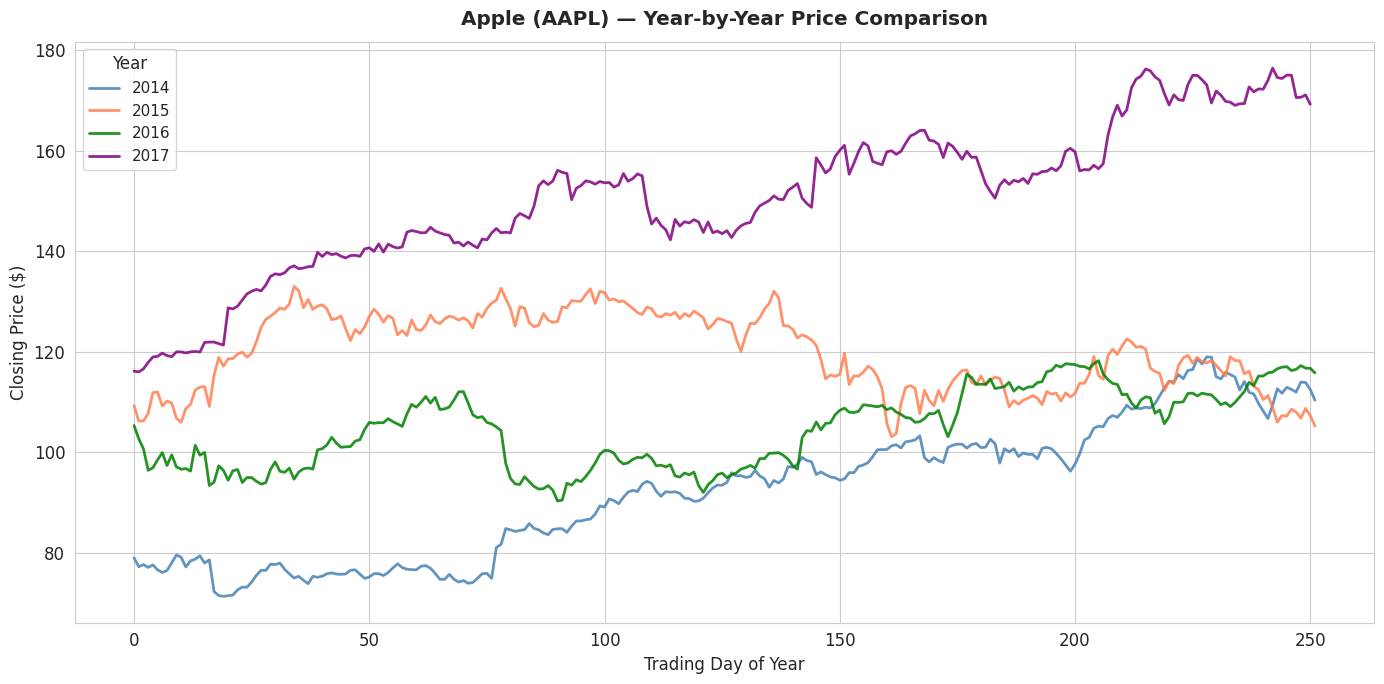

 Saved: yearly_comparison.png


In [ ]:
plt.figure(figsize=(14, 7))

colors = ['steelblue', 'coral', 'green', 'purple']
years = sorted(apple.index.year.unique())

for year, color in zip(years, colors):
    yearly = apple[apple.index.year == year]['close']
    plt.plot(range(len(yearly)), yearly.values,
             color=color, linewidth=2, label=str(year), alpha=0.85)

plt.title('Apple (AAPL) — Year-by-Year Price Comparison',
          fontweight='bold', pad=12)
plt.xlabel('Trading Day of Year')
plt.ylabel('Closing Price ($)')
plt.legend(title='Year', fontsize=11)
plt.tight_layout()
plt.savefig('yearly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: yearly_comparison.png")

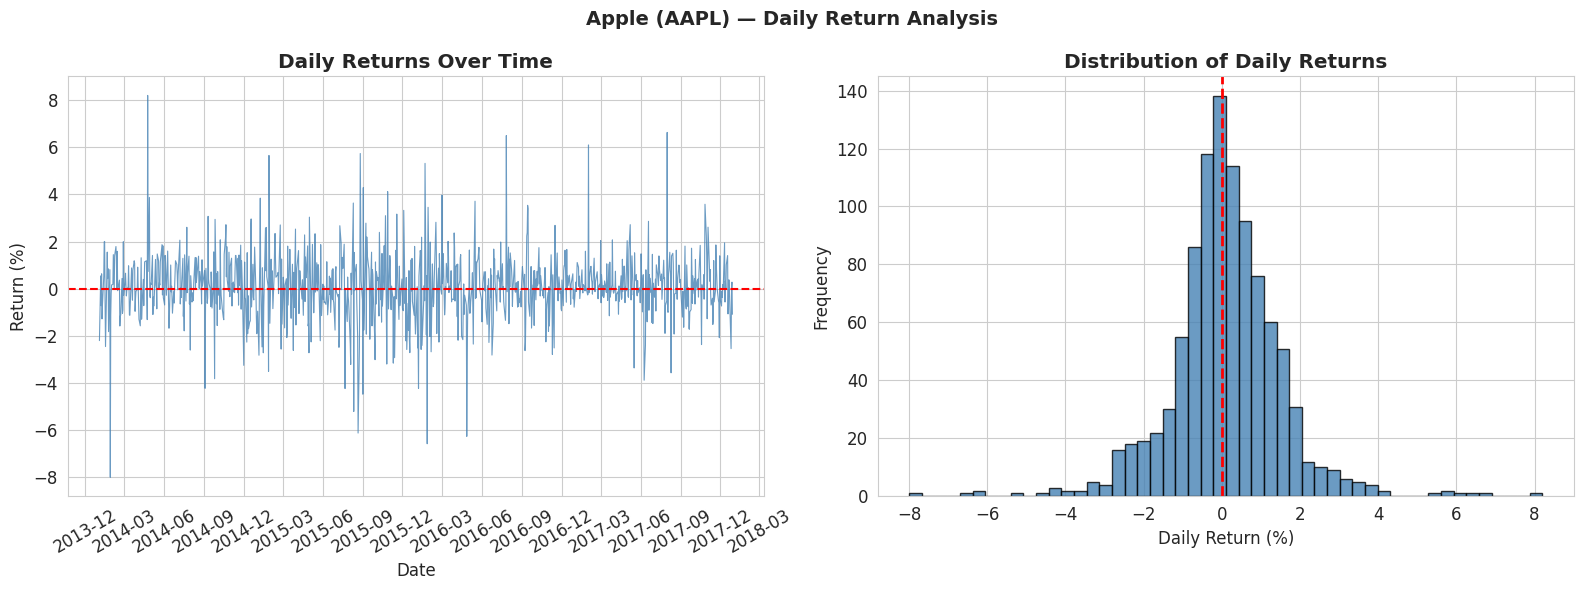

 Saved: daily_returns.png


In [ ]:
apple['daily_return'] = apple['close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Daily returns over time
axes[0].plot(apple.index, apple['daily_return'],
             color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Daily Returns Over Time', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return (%)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Distribution of returns
axes[1].hist(apple['daily_return'].dropna(),
             bins=50, color='steelblue',
             edgecolor='black', alpha=0.8)
axes[1].axvline(x=0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Distribution of Daily Returns', fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Apple (AAPL) — Daily Return Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('daily_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: daily_returns.png")

In [ ]:
print("=" * 55)
print("    FINAL SUMMARY — TIME SERIES ANALYSIS")
print("=" * 55)
print(f"\n Company         : Apple Inc. (AAPL)")
print(f" Period          : 2014-01-02 → 2017-12-29")
print(f" Starting price  : ${apple['close'].iloc[0]:.2f}")
print(f" Ending price    : ${apple['close'].iloc[-1]:.2f}")
total_return = ((apple['close'].iloc[-1] / apple['close'].iloc[0]) - 1) * 100
print(f" Total return    : {total_return:.1f}%")
print(f"\n Lowest price    : ${apple['close'].min():.2f}")
print(f" Highest price   : ${apple['close'].max():.2f}")
print(f" Avg daily return: {apple['daily_return'].mean():.4f}%")
print(f"  Volatility(std) : {apple['daily_return'].std():.4f}%")
print(f"\n Key Observations:")
print(f"   - Clear upward trend visible from 2014 to 2017")
print(f"   - Seasonal patterns detected via decomposition")
print(f"   - 30-day MA smooths short-term fluctuations")
print(f"   - 90-day MA reveals the long-term trend clearly")
print("\n Time Series Analysis completed!")

    FINAL SUMMARY — TIME SERIES ANALYSIS

 Company         : Apple Inc. (AAPL)
 Period          : 2014-01-02 → 2017-12-29
 Starting price  : $79.02
 Ending price    : $169.23
 Total return    : 114.2%

 Lowest price    : $71.40
 Highest price   : $176.42
 Avg daily return: 0.0860%
  Volatility(std) : 1.4309%

 Key Observations:
   - Clear upward trend visible from 2014 to 2017
   - Seasonal patterns detected via decomposition
   - 30-day MA smooths short-term fluctuations
   - 90-day MA reveals the long-term trend clearly

 Time Series Analysis completed!
